In [1]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
from astropy.table import Column, join, Table, vstack, hstack
from astropy.io import ascii
from HMXB_pipeline_class import pipeline
import astropy.coordinates as coords
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import corner
from datetime import datetime
import os
from astropy.io.votable import parse
import emcee

Important: Gaia archive will be intermittently unavailable due to scheduled maintenance (deployment of a new version) on Wednesday 4th from 11h to 12h


In [2]:
from Galactic_traceback import GalacticTraceback
from Galactic_traceback_for_MCMC import galactic_path_MCMC as gpMCMC

In [3]:
cwd = os.getcwd()
cwd
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
csv_files  = home_files + 'DATA/'
csv_files

'/home/karan/Documents/UvA/Thesis/DATA/'

In [4]:
HMXB_table = ascii.read(csv_files+'HMXB_20250602_.ecsv',format='ecsv')

In [5]:
HMXB_table['Name']

X Per
EXO 051910+3737.7
RX J0440.9+4431
XTE J0421+560
EM* AS 14
gam Cas
IGR J00370+6122
V 0332+53
Swift J0243.6+6124
LS I+61 303
RX J0146.9+6121


# Names
## 4U 2206+543


In [6]:
star_2206 = HMXB_table[HMXB_table['source_id'] == 2005653524280214400]
star_2206
# star_2206['RV'] = -73.6
# star_2206['RV_err'] = 9.4

source_id,ra,ra_error,dec,dec_error,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,radial_velocity,radial_velocity_error,phot_g_mean_mag,l,b,ruwe,distance_bj,distance_bj_low,distance_bj_high,Name,Mx,Mx_err,Mo,Mo_err,RV,RV_err,Period,Period_err,Spin_period,Spin_period_err,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err,SpType,Mod_SpType,SpColor,pm_l_err,pm_b_err,l_err,b_err,V_pec_tan_err,V_pec_3d_err
,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas,mas,km / s,km / s,mag,deg,deg,,kpc,kpc,kpc,,,,,,km / s,km / s,,,,,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc,,,,,,,,km / s,km / s
int64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float64,float32,float64,float64,float64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str21,str17,str10,float64,float64,float64,float64,float64,float64
2005653524280214400,331.98428755192987,0.012050482,54.518432170802825,0.011263556,-4.172517978480273,0.0151939755,-3.316562372366748,0.013615789,0.3050532500378427,0.013605253,--,--,9.743357,100.60324189142595,-1.1059224650682717,0.9785323,3.1674092000000003,3.0472979000000002,3.3326724,4U 2206+543,--,--,18.0,--,-54.5,1.0,9.558,0.04,392.0,--,3.2781161973391435,-5.320924798903758,-0.31185178362654387,9.27089679752768,240.70091275872343,-23.97988925926849,0.8737514207648808,-0.5207464477558823,-11.231698001733578,-5.1783237426971525,-0.03083334516427316,-27.277923747094576,15.677751490132476,-15.990378251171846,-1.0163524769714867,0.2397280092936116,22.393840412084316,0.14620267017950472,O9.5IIIe,xkcd:bright blue,xkcd:blue,0.01469354835801458,0.007325491365767859,0.011726550513661987,0.005989686069167577,8.273596263845704,11.971901069446087


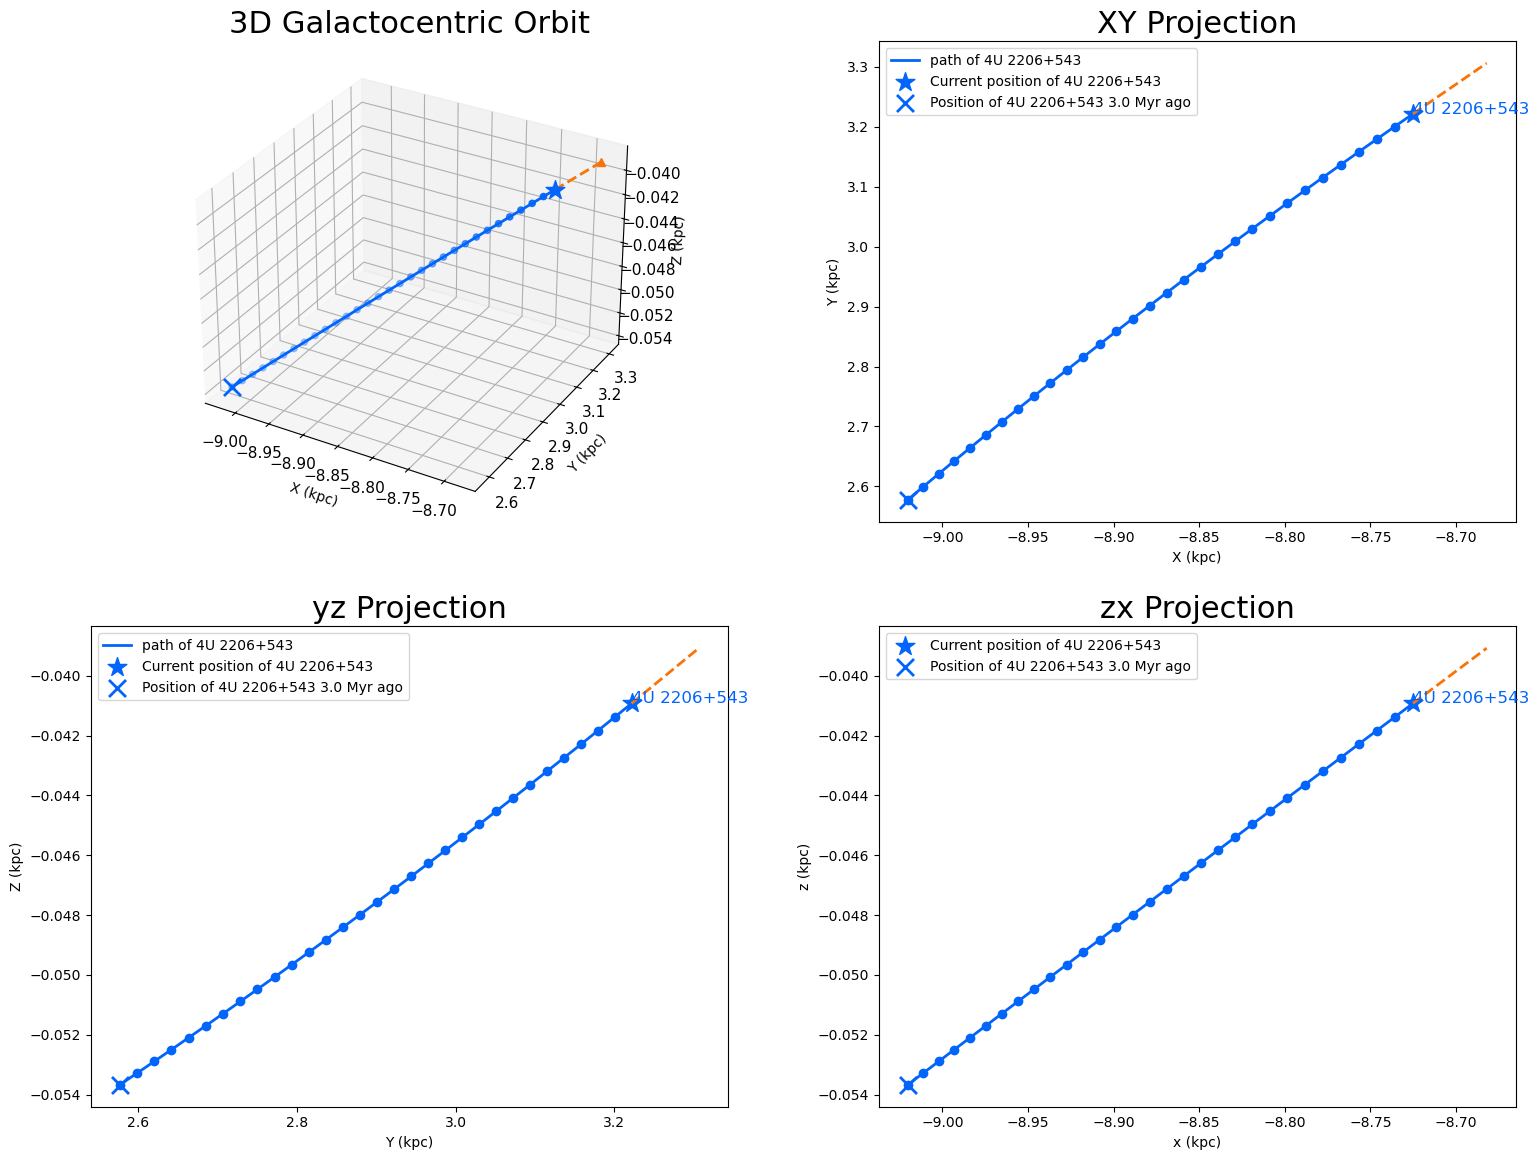

In [7]:
GalacticTraceback(star_2206,int_time=-3.0).plot_in_galactocentric(star_2206,cluster=None,figname=None,savefig=False)

# Match with Cep Ob1

In [8]:
from astropy.io.votable import parse

# Replace with your file path
votable = parse(csv_files+"Lower_cen_crux")

cep_ob1 = ascii.read(csv_files+'CepOb1_params.ecsv',format='ecsv')


In [9]:
Simbad.query_object("Cep ob1")

main_id,ra,dec,coo_err_maj,coo_err_min,coo_err_angle,coo_wavelength,coo_bibcode,matched_id
,deg,deg,mas,mas,deg,,,
object,float64,float64,float32,float32,int16,str1,object,object
Ass Cep OB 1,337.25,56.6,--,--,--,,2003AstL...29..311S,Ass Cep OB 1


# Cep Ob1 Members MEl'nik 2017

In [10]:
cep_ob1_members = Table.read(csv_files+'Cep_ob1_members.fit')
cep_ob1_members

Name,Ass,sp,r,_RA_icrs,_DE_icrs,recno
,,,kpc,deg,deg,
bytes21,bytes9,bytes4,float64,float64,float64,int32
HDE 235673,CEP OB1,O6.5,2.78,329.4885,52.8647,524
BD +54 2629,CEP OB1,B1,2.78,326.941,55.3202,525
HD 209900,CEP OB1,A0,2.78,331.404,53.5512,526
HD 210809,CEP OB1,O9.,2.78,332.9152,52.4312,527
HOAG 5,CEP OB1,B2,2.78,329.9784,57.0497,528
HOAG 7,CEP OB1,B2,2.78,329.9784,57.0497,529
HOAG 2,CEP OB1,B0,2.78,329.9784,57.0497,530
BD +53 2820,CEP OB1,B0,2.78,333.411,54.3746,531


In [11]:
cep_ob1_members.rename_columns(['_RA_icrs','_DE_icrs'],['ra','dec'])

# I need pmra and pmdec for cep ob1

In [12]:
import pandas as pd
df = pd.read_fwf(csv_files+'stac1780_supplemental_files/table1.dat', comment='#')
df
cep_ob1_df = df.iloc[[80, 120, 121, 122]]
cep_ob1_ra = df.iloc[:, [3]]
cep_ob1_dec = df.iloc[:, [4]]
cep_ob1_df

,0,353.447,+15.927,-12.478,-19.000,1704,5.14,152.96,21,9.91,23.62,999.99,999.99.1,4.000
80,81,351.815,-6.169,2.685,-2.056,1217,3.94,83.66,16,1.66,1.62,92.48,8.39,1.327
120,21,101.510,-2.015,-3.561,-3.212,3368,1.06,62.46,25,3.30,3.26,19.34,1.60,2.536
121,22,102.317,-1.676,-3.547,-3.088,3876,1.91,129.50,10,2.62,2.63,999.99,999.99,0.666
122,23,110.530,2.904,-1.134,-2.087,841,1.84,27.04,24,1.09,1.08,60.91,4.27,1.164


In [13]:
cep_ob1_ra.mean()

-12.478   -2.722033
dtype: float64

In [14]:
cep_ob1_galactic = SkyCoord(l=104.20*u.deg, b=0.94*u.deg,pm_l_cosb = -4.46*u.mas/u.yr, pm_b = -0.67*u.mas/u.yr, radial_velocity=-58.2*u.km/u.s,frame='galactic')

cep_ob1_icrs = cep_ob1_galactic.transform_to(coords.ICRS)
cep_ob1_icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (335.27400269, 58.23493893)
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-3.38169559, -2.98406349, -58.2)>

In [15]:
#mel-link 2017
cep_ob1_params = Table([['Cep Ob1'],[2.78]*u.kpc, [337.25]*u.deg,[56.6]*u.deg, [-2.722]*u.mas/u.yr,[-1.14]*u.mas/u.yr,[-58.2]*u.km/u.s,[1/2.78]*u.mas],
                       names=['Name',"distance_bj", "ra", "dec", "pmra", "pmdec", "RV",'parallax'])
cep_ob1_params

Name,distance_bj,ra,dec,pmra,pmdec,RV,parallax
,kpc,deg,deg,mas / yr,mas / yr,km / s,mas
str7,float64,float64,float64,float64,float64,float64,float64
Cep Ob1,2.78,337.25,56.6,-2.722,-1.14,-58.2,0.3597122302158274


In [16]:
print(star_2206['RV'])

  RV  
km / s
------
 -54.5


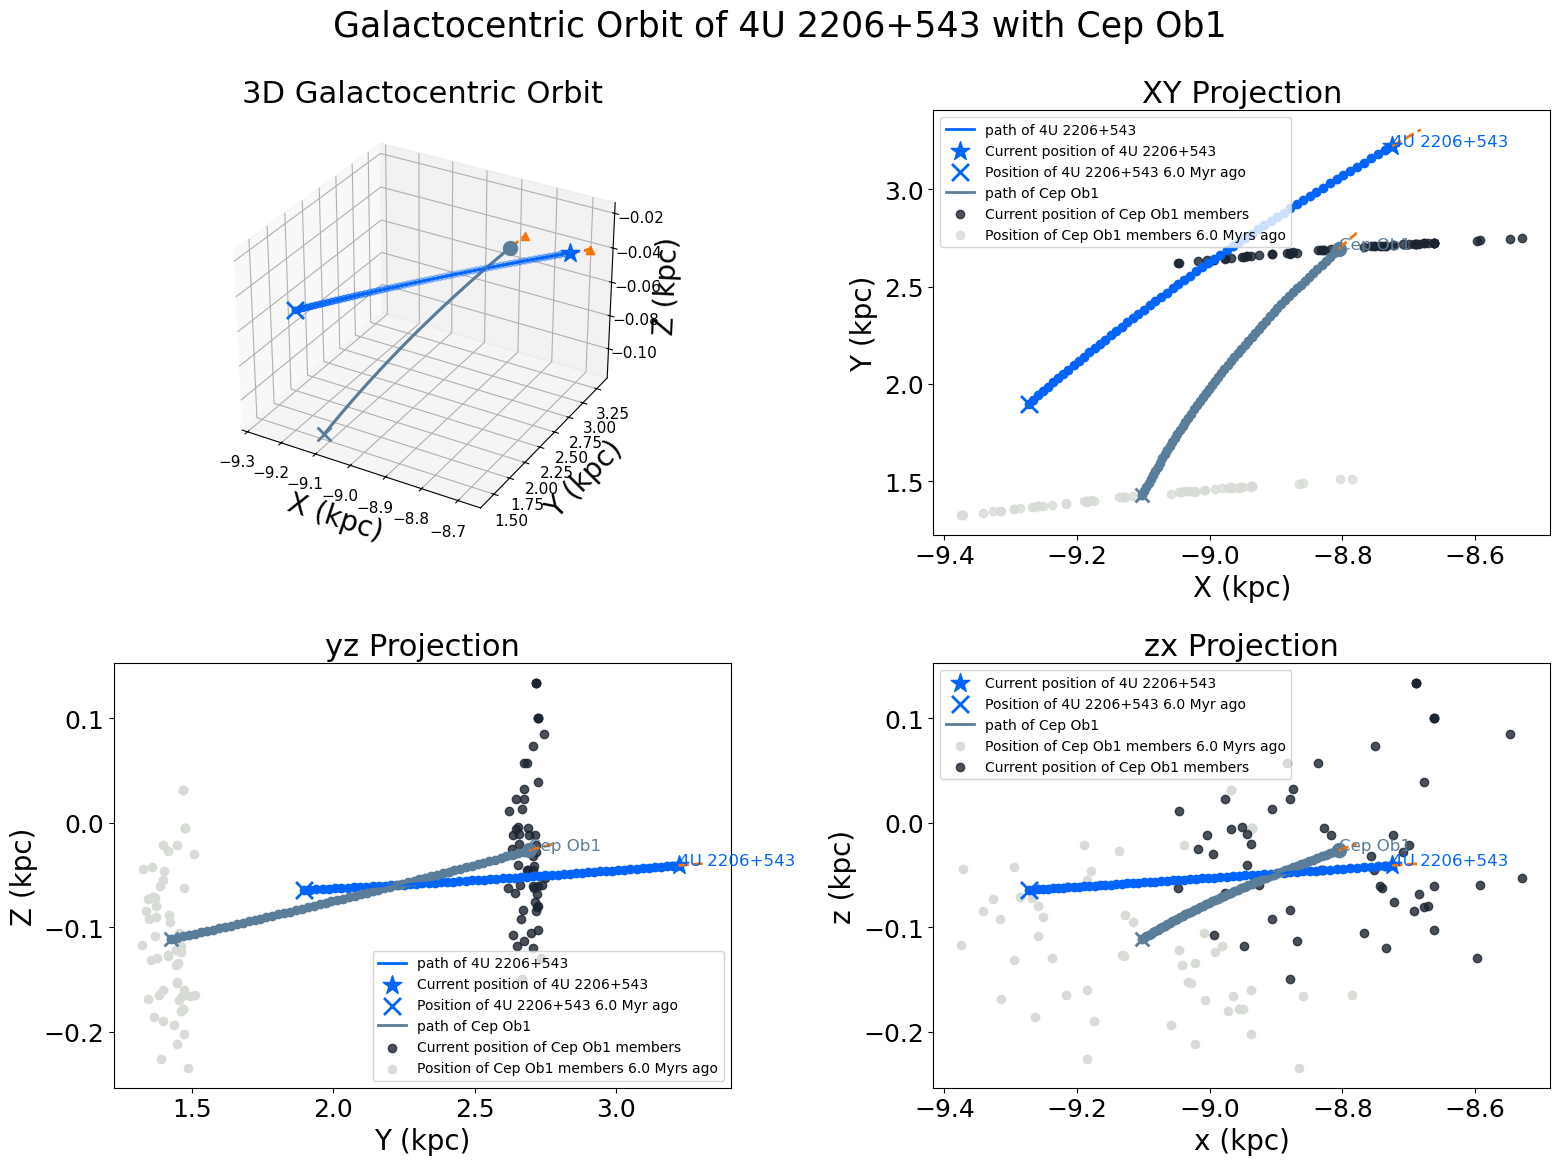

In [17]:
GalacticTraceback(star_2206,int_time=-6.0).plot_in_galactocentric(star_2206,cluster=cep_ob1_params,cluster_members=cep_ob1_members,figname=None,savefig=False)

relative velocity 42.54580485820603 km / s, std 0.4015548201653298 km / s
497.79290714504964 pc
-4.6e-06 Myr ago


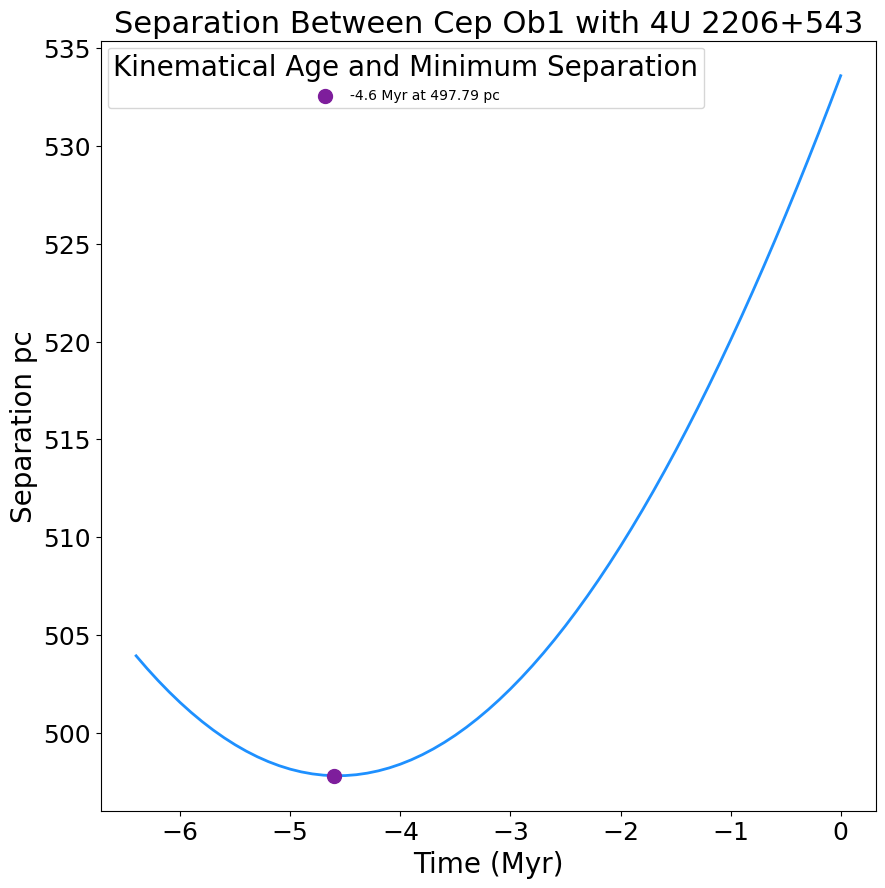

In [18]:
GalacticTraceback(star_2206,int_time=-6.4).plot_separation(star_2206,cluster=cep_ob1_params,savefig=False)

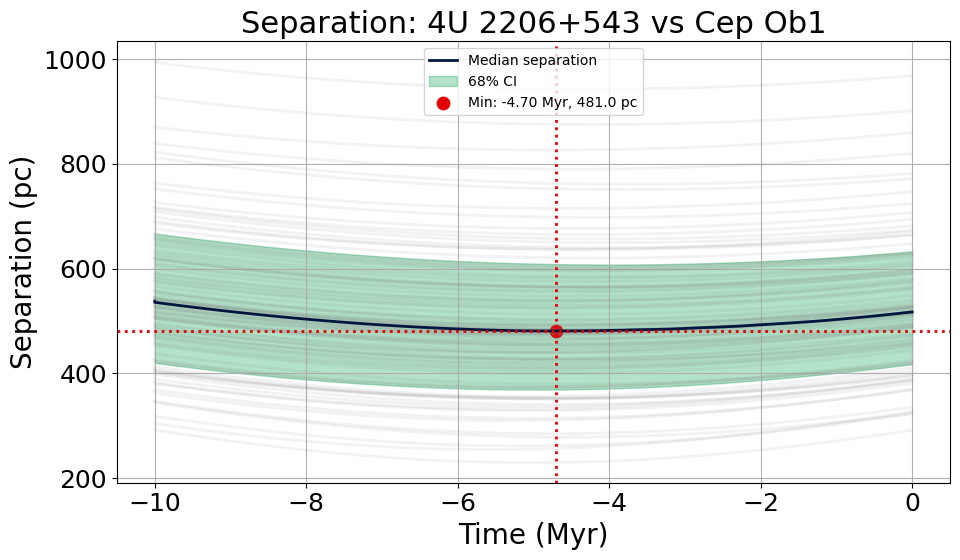

In [19]:
GalacticTraceback(star_2206,int_time=-10.0).plot_separation_with_uncertainty(star_2206,cluster=cep_ob1_params,savefig=False)

In [20]:
names_x = ['4U 2206_543','CEP OB1']
gpmc_args = {'backend_name':'4U2206_Cepob1_chain','star_params':star_2206,'cluster_params':cep_ob1_params, 'cluster_radius':None,'int_time':-10.0,
            'names':names_x}

In [21]:
sample_2206, state_2206 = gpMCMC().start_mcmc(**gpmc_args)

Compling MCMC for 4U 2206_543 and CEP OB1


100%|███████████████████████████████████████████████████████████| 1000/1000 [03:52<00:00,  4.31it/s]


In [22]:
backend_2206 = emcee.backends.HDFBackend('4U2206_Cepob1_chain.h5')

In [23]:
chain_2206 = backend_2206.get_chain(thin=10, flat=True)
blobs_2206 = backend_2206.get_blobs(thin=10,flat=True)
kinematic_ages = np.array([b[0] for b in blobs_2206])
min_separations = np.array([b[1] for b in blobs_2206])

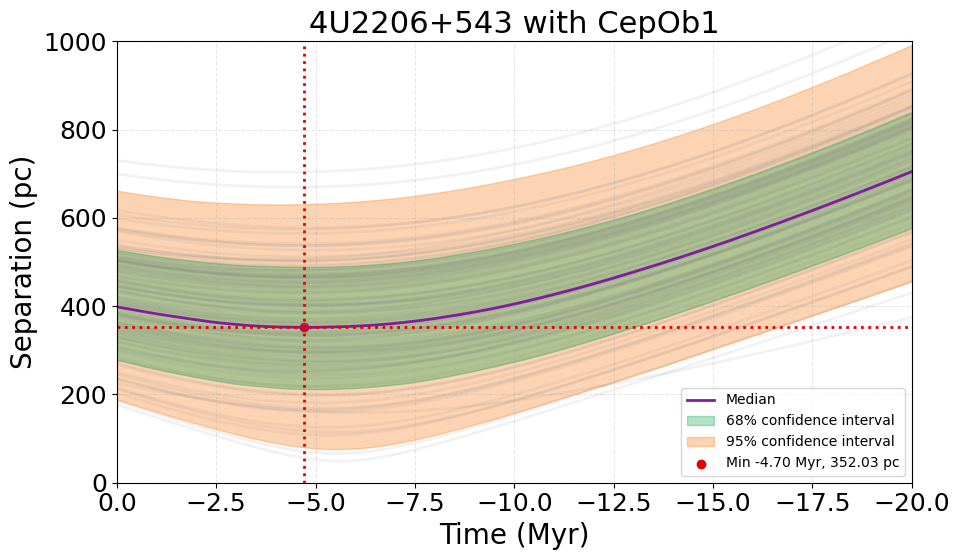

In [24]:
gpMCMC().compute_full_separations_and_plot(flat_chain=chain_2206, cluster_params=cep_ob1_params, int_time=-20.0, star_ra=star_2206['ra'], 
                                  star_dec=star_2206['dec'],
                                  cluster_radius=None, title='4U2206+543 with CepOb1',
                                  n_samples=1000)

# DO it again with RV = -73.6 km/s from Hambaryan

In [25]:
star_2206['RV'] = -73.6
star_2206['RV_err'] = 9.4

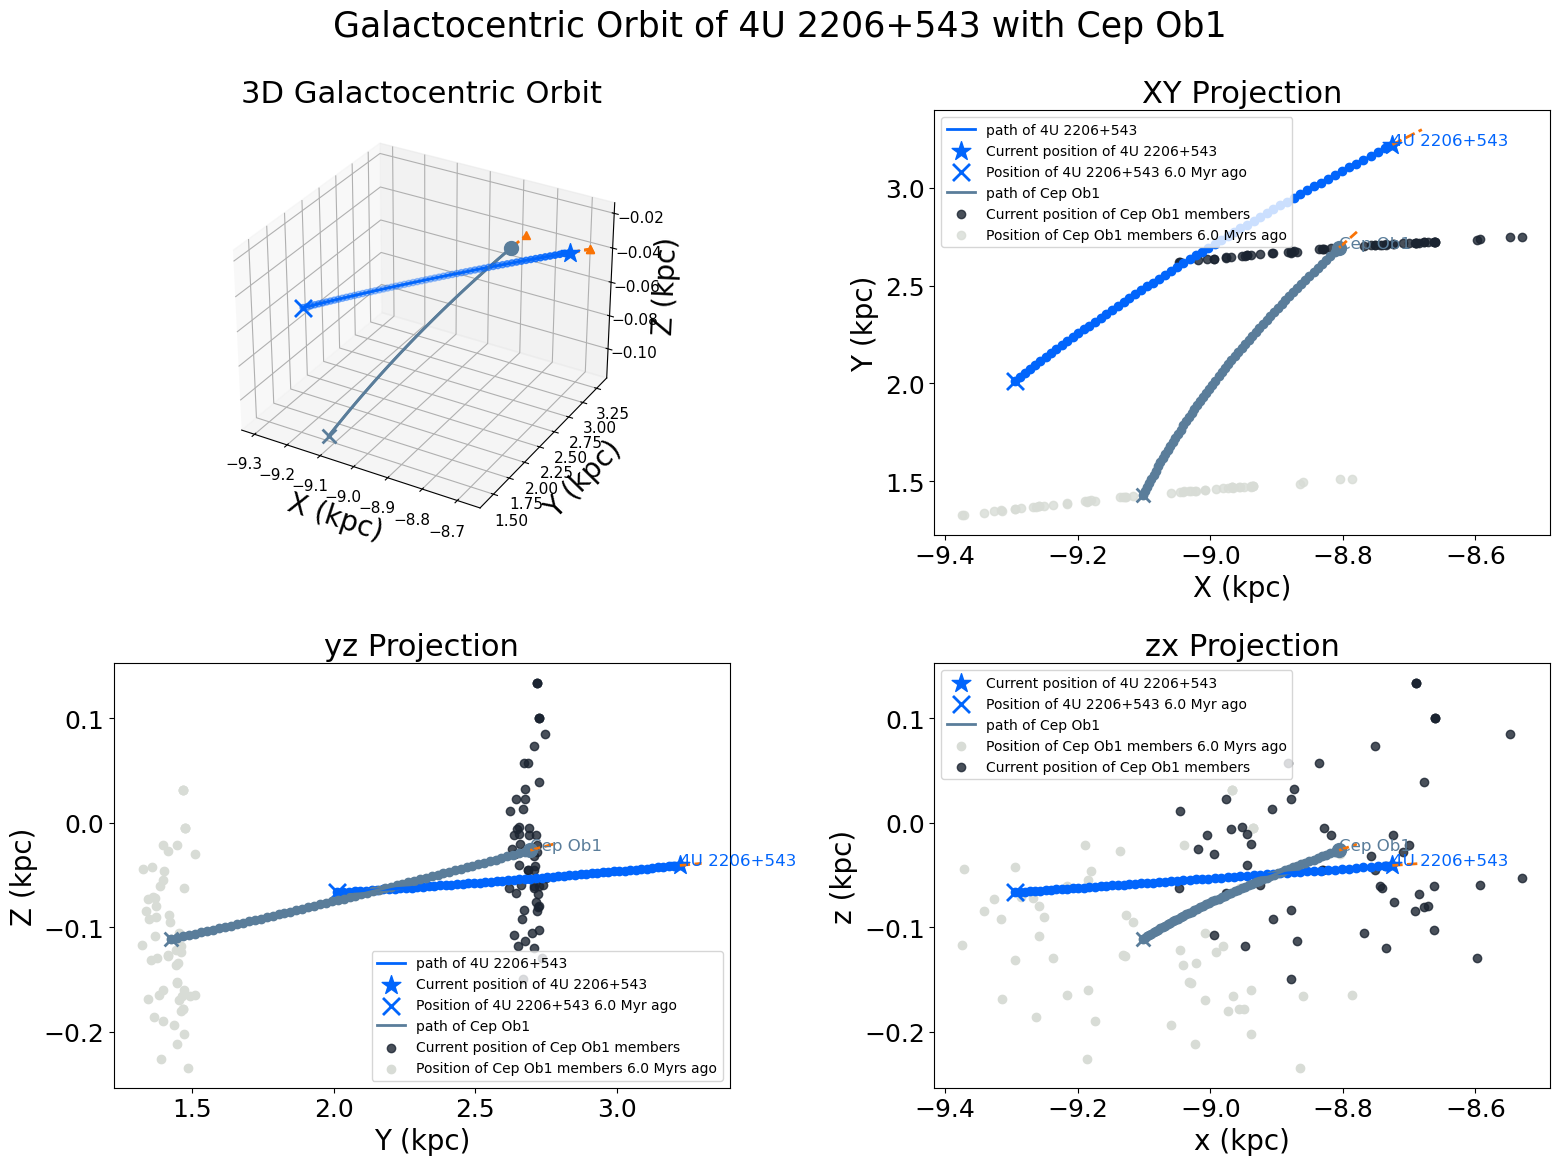

In [26]:
GalacticTraceback(star_2206,int_time=-6.0).plot_in_galactocentric(star_2206,cluster=cep_ob1_params,cluster_members=cep_ob1_members,figname=None,savefig=False)

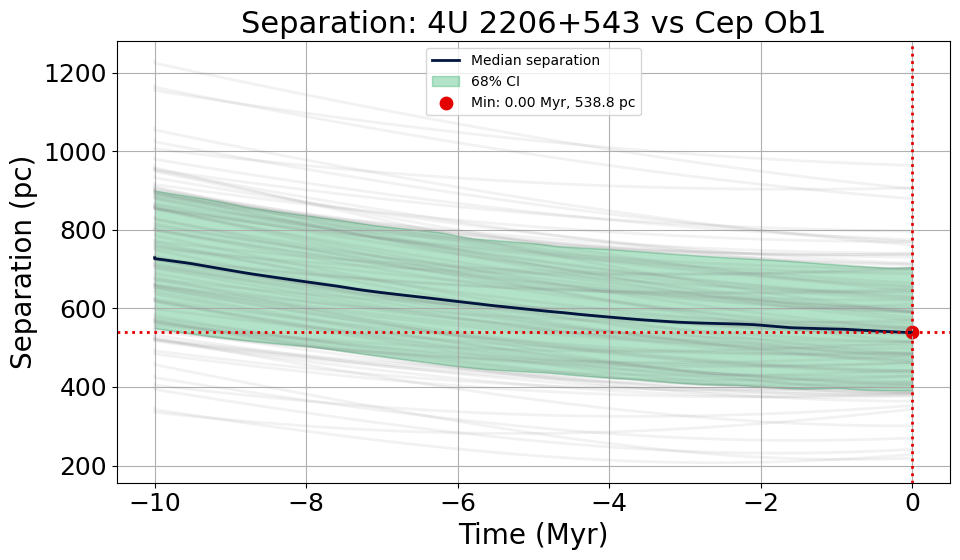

In [27]:
GalacticTraceback(star_2206,int_time=-10.0).plot_separation_with_uncertainty(star_2206,cluster=cep_ob1_params,savefig=False)

In [28]:
names_x = ['4U 2206_543','CEP OB1']
gpmc_args_ham = {'backend_name':'4U2206_Cepob1_chain_WITH_HAMBARYAN','star_params':star_2206,'cluster_params':cep_ob1_params, 'cluster_radius':None,'int_time':-10.0,
            'names':names_x}

In [29]:
print(star_2206['RV'])

  RV  
km / s
------
 -73.6


In [30]:
sample_2206, state_2206 = gpMCMC().start_mcmc(**gpmc_args_ham)

Compling MCMC for 4U 2206_543 and CEP OB1


100%|███████████████████████████████████████████████████████████| 1000/1000 [04:13<00:00,  3.94it/s]


In [31]:
backend_2206_ham = emcee.backends.HDFBackend('4U2206_Cepob1_chain_WITH_HAMBARYAN.h5')

In [32]:
chain_2206_ham = backend_2206_ham.get_chain(thin=10, flat=True)
blobs_2206_ham = backend_2206_ham.get_blobs(thin=10,flat=True)
kinematic_ages_ham = np.array([b[0] for b in blobs_2206_ham])
min_separations_ham = np.array([b[1] for b in blobs_2206_ham])

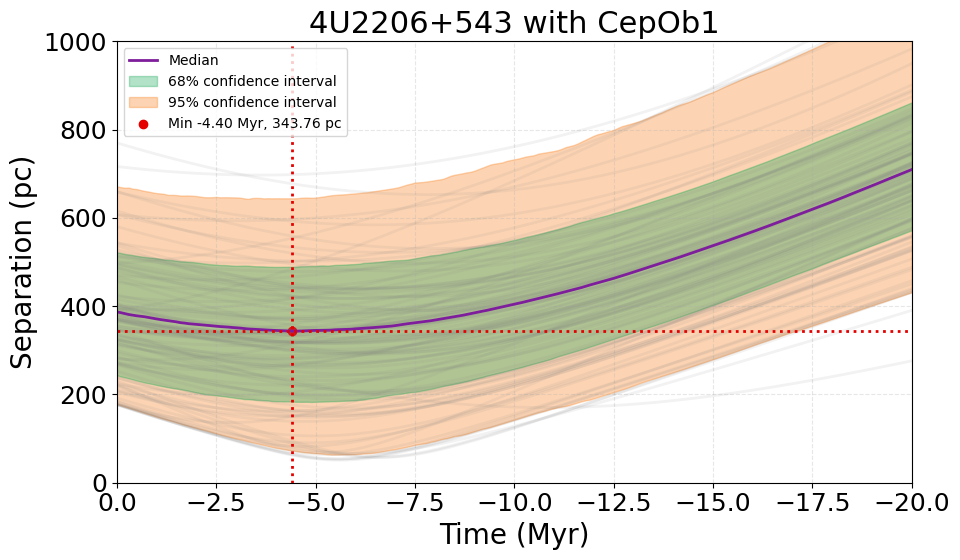

In [33]:
gpMCMC().compute_full_separations_and_plot(flat_chain=chain_2206_ham, cluster_params=cep_ob1_params, int_time=-20.0, star_ra=star_2206['ra'], 
                                  star_dec=star_2206['dec'],
                                  cluster_radius=None, title='4U2206+543 with CepOb1',
                                  n_samples=2000)